# Maintenance Prédictive – Machine Learning
**Dataset :** `industrial_machine_maintenance.csv`  
**Objectif principal :** Prédire `failure_within_24h` (classification binaire)  
**Objectifs secondaires :** Prédire `failure_type` (multi-classes) et `rul_hours` (régression)

## 1. Importation des librairies

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Librairies EDA chargees OK')

Librairies EDA chargees OK


## 2. Chargement des données

In [54]:
df = pd.read_csv('../data/industrial_machine_maintenance.csv', parse_dates=['timestamp'])
print(f'Shape : {df.shape}')
df.head()

Shape : (24042, 15)


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                24042 non-null  datetime64[us]
 1   machine_id               24042 non-null  int64         
 2   machine_type             24042 non-null  str           
 3   vibration_rms            23042 non-null  float64       
 4   temperature_motor        23208 non-null  float64       
 5   current_phase_avg        23311 non-null  float64       
 6   pressure_level           23118 non-null  float64       
 7   rpm                      23509 non-null  float64       
 8   operating_mode           24042 non-null  str           
 9   hours_since_maintenance  24042 non-null  float64       
 10  ambient_temp             24042 non-null  float64       
 11  rul_hours                24042 non-null  float64       
 12  failure_within_24h       24042 non-null  in

In [56]:
df.describe()

,timestamp,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000
mean,2024-01-08 00:06:30.111721,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,27.812510,0.148074,608.870144
min,2024-01-01 00:00:00,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.500000,0.000000,0.000000
25%,2024-01-04 12:24:13.750000,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.500000,0.000000,0.000000
50%,2024-01-08 00:11:30,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,22.570000,0.000000,0.000000
75%,2024-01-11 13:24:32.500000,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,46.410000,0.000000,0.000000
max,2024-01-14 23:59:38,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,98.340000,1.000000,7995.000000
std,NaN,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,26.393801,0.355181,1566.793887


## 3. Analyse exploratoire (EDA)

Valeurs manquantes :
vibration_rms        1000
pressure_level        924
temperature_motor     834
current_phase_avg     731
rpm                   533
dtype: int64


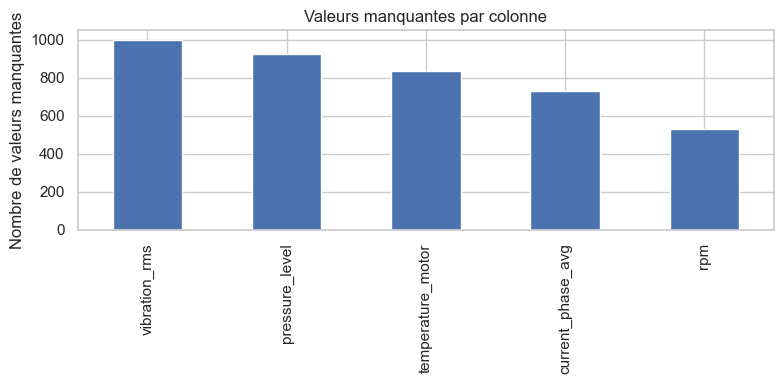

In [57]:
# Valeurs manquantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Valeurs manquantes :')
print(missing)

if not missing.empty:
    missing.plot(kind='bar', figsize=(8, 4), title='Valeurs manquantes par colonne')
    plt.ylabel('Nombre de valeurs manquantes')
    plt.tight_layout()
    plt.show()

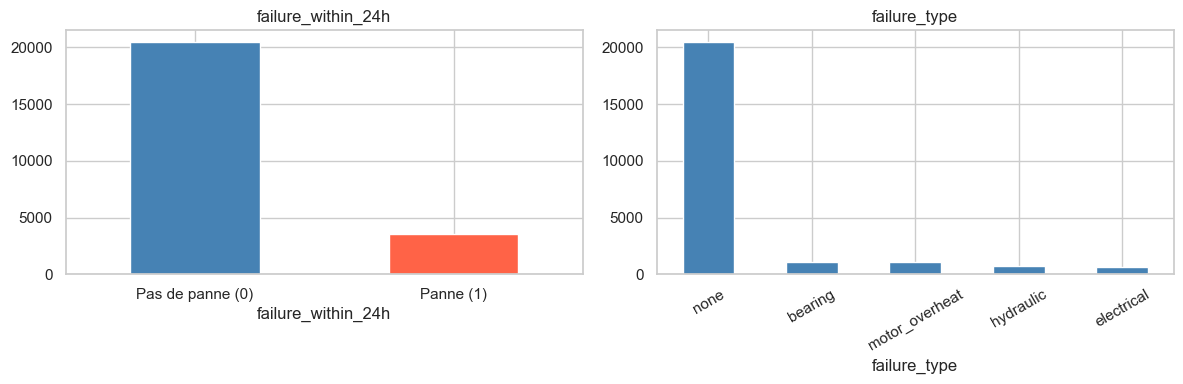

In [58]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['failure_within_24h'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('failure_within_24h')
axes[0].set_xticklabels(['Pas de panne (0)', 'Panne (1)'], rotation=0)

df['failure_type'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('failure_type')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

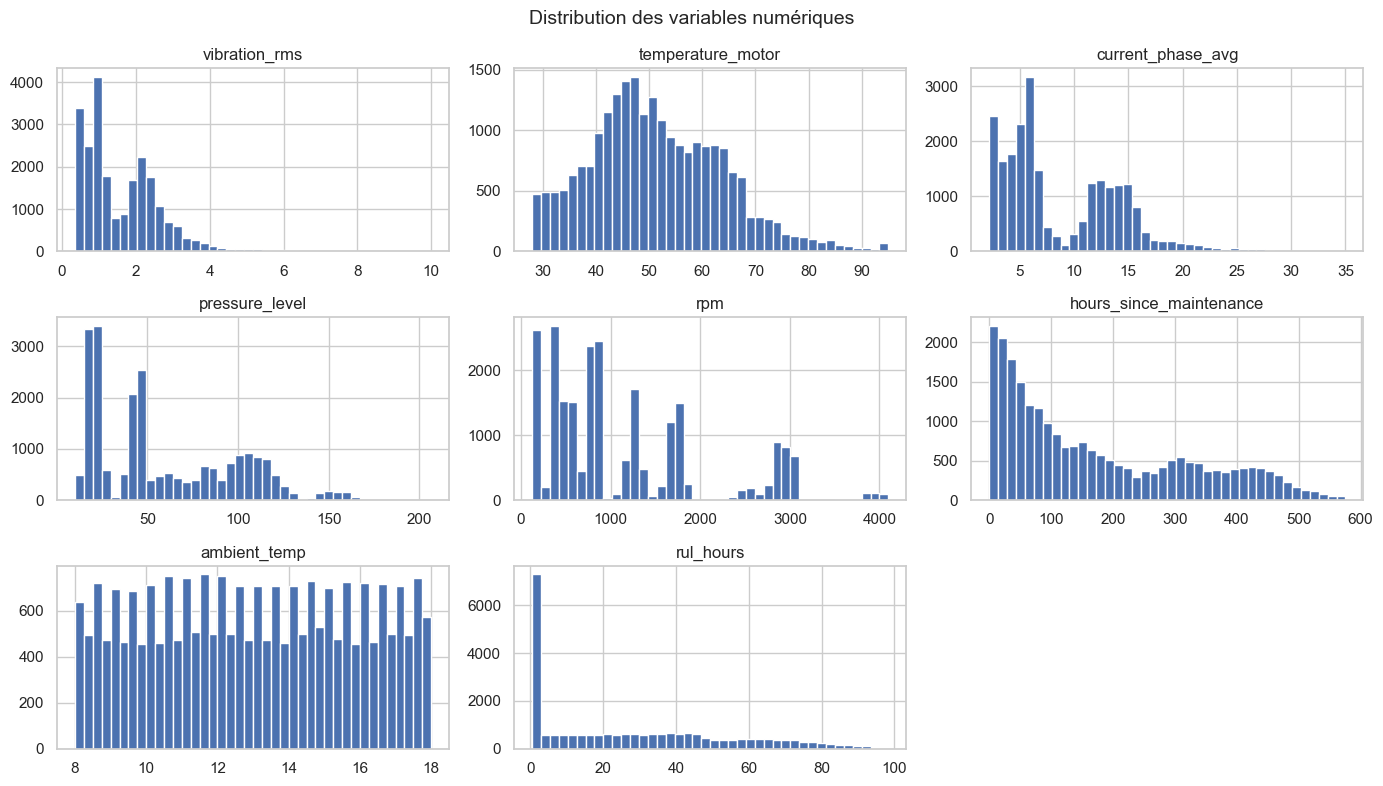

In [59]:
# Distribution des variables numériques
num_cols = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
            'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours']

df[num_cols].hist(figsize=(14, 8), bins=40, edgecolor='white')
plt.suptitle('Distribution des variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

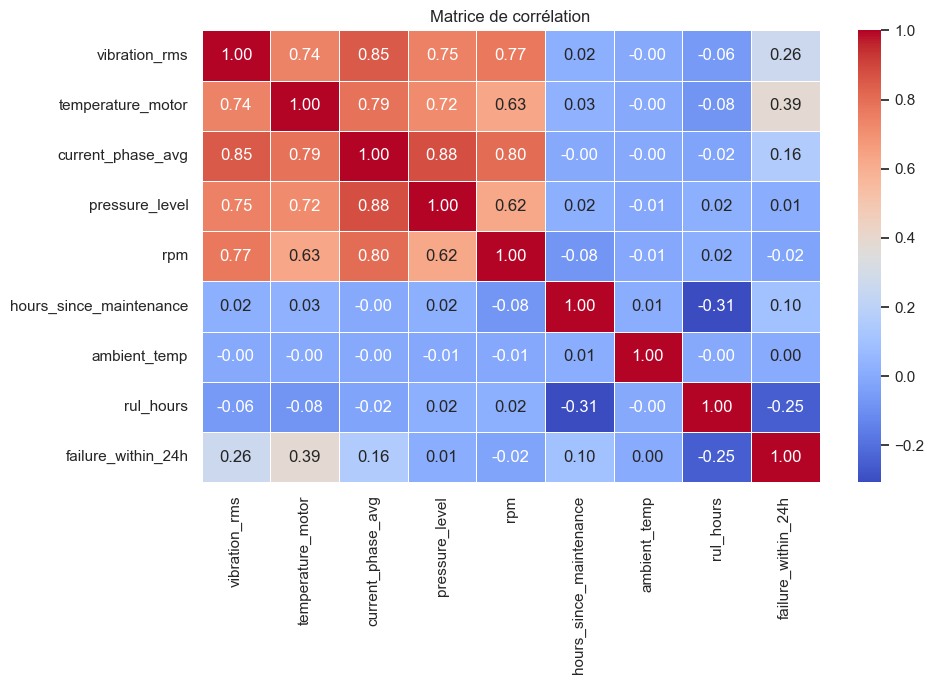

In [60]:
# Matrice de corrélation
plt.figure(figsize=(10, 7))
corr = df[num_cols + ['failure_within_24h']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

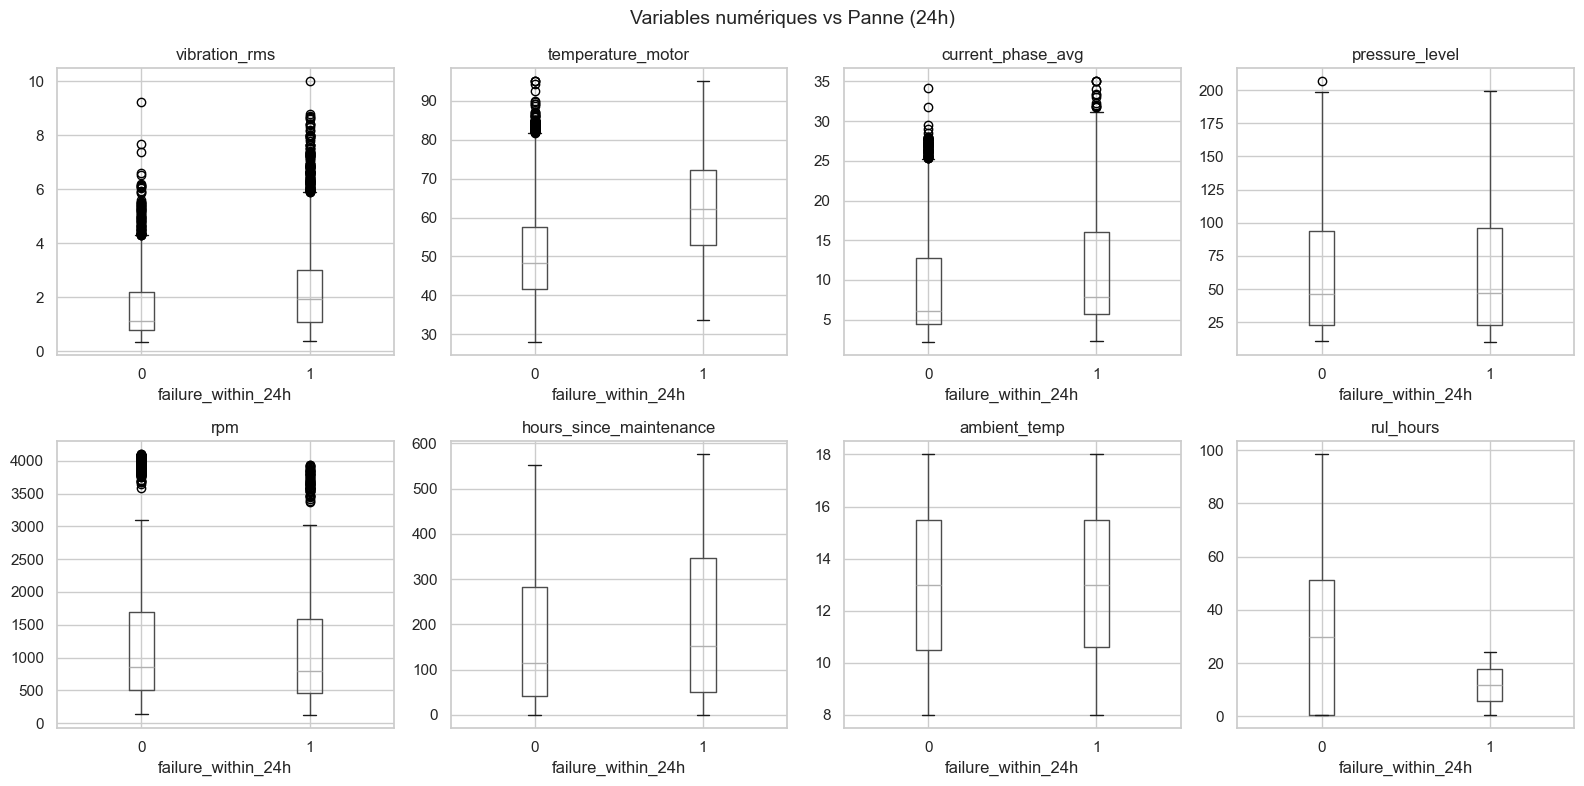

In [61]:
# Boxplots : variables numériques vs failure_within_24h
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='failure_within_24h', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('failure_within_24h')

plt.suptitle('Variables numériques vs Panne (24h)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Pipeline complet (preprocessing -> entrainement -> evaluation)

In [62]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # pointe vers Sujet_1/

from src.preprocessing import load_data, engineer_features, get_train_test_split, FEATURES, TARGET
from src.train import build_pipelines, cross_validate_models, train_and_save
from src.evaluate import evaluate_models, plot_confusion_matrices, plot_roc_curves, plot_feature_importance

### 4.1 Preparation des donnees

In [63]:
df_clean = load_data()
df_clean = engineer_features(df_clean)
X_train, X_test, y_train, y_test = get_train_test_split(df_clean)

print(f'Train : {X_train.shape[0]} lignes  |  Test : {X_test.shape[0]} lignes')
print(f'Taux de pannes (train) : {y_train.mean():.2%}')

Train : 19233 lignes  |  Test : 4809 lignes
Taux de pannes (train) : 14.81%


### 4.2 Cross-validation (StratifiedKFold 5 folds)

      Logistic Regression  Random Forest  XGBoost
mean               0.9492         0.9948   0.9970
std                0.0044         0.0007   0.0006


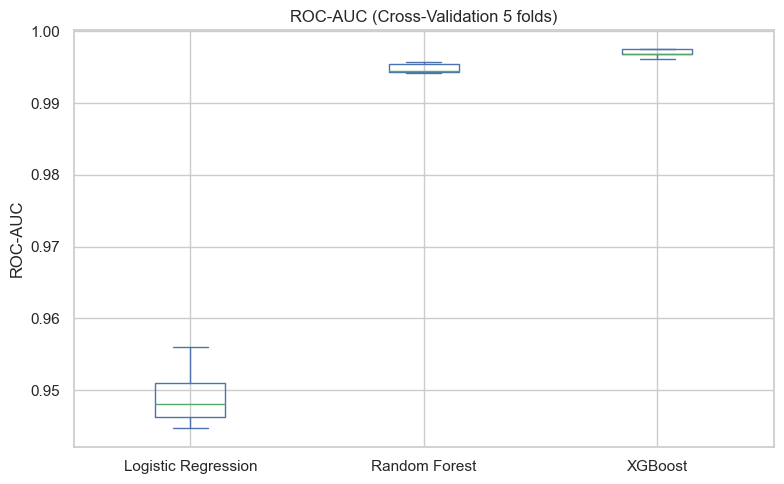

In [64]:
models = build_pipelines()
cv_results = cross_validate_models(models, X_train, y_train)

cv_df = pd.DataFrame(cv_results)
print(cv_df.agg(['mean', 'std']).round(4))

cv_df.plot(kind='box', figsize=(8, 5))
plt.title('ROC-AUC (Cross-Validation 5 folds)')
plt.ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

### 4.3 Entrainement final + sauvegarde

In [65]:
trained_models = train_and_save(models, X_train, y_train)

FileNotFoundError: [Errno 2] No such file or directory: 'models/logistic_regression_failure_24h.joblib'

### 4.4 Evaluation sur le jeu de test

In [ ]:
results_df = evaluate_models(trained_models, X_test, y_test)
results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modèle,,,,,
Logistic Regression,0.9025,0.6202,0.8806,0.7278,0.9515
Random Forest,0.9755,0.9393,0.8919,0.9150,0.9954
XGBoost,0.9838,0.9529,0.9368,0.9448,0.9973


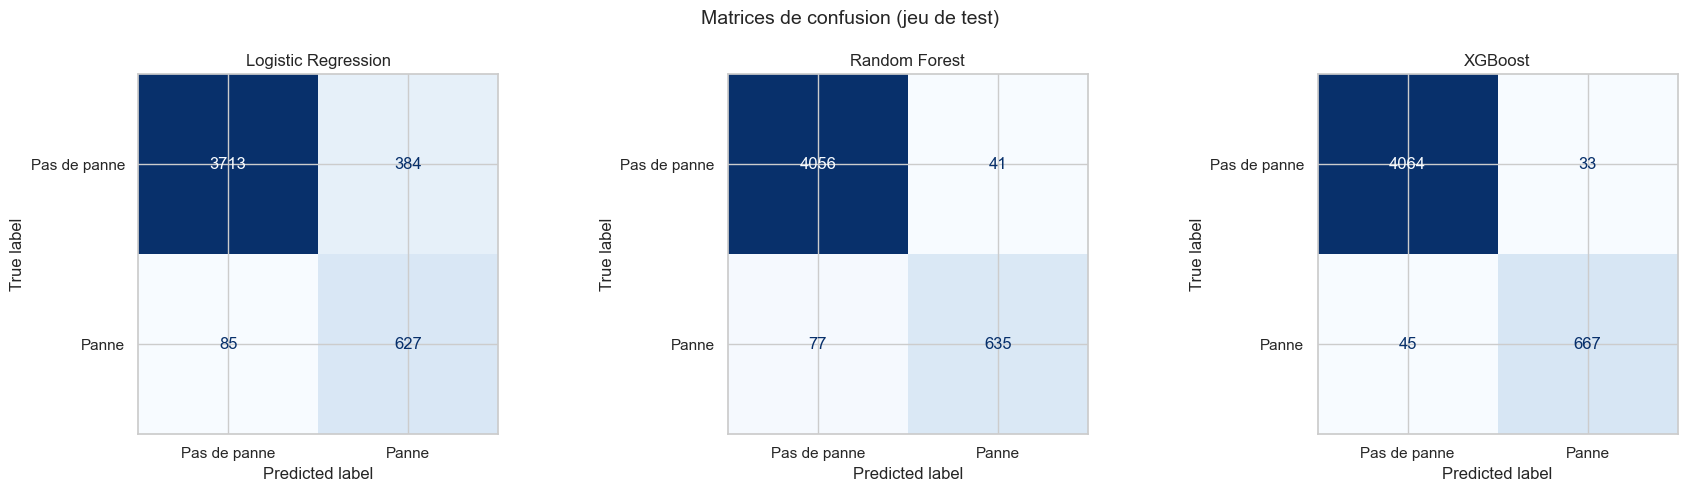

In [ ]:
fig_cm = plot_confusion_matrices(trained_models, X_test, y_test)
plt.show()

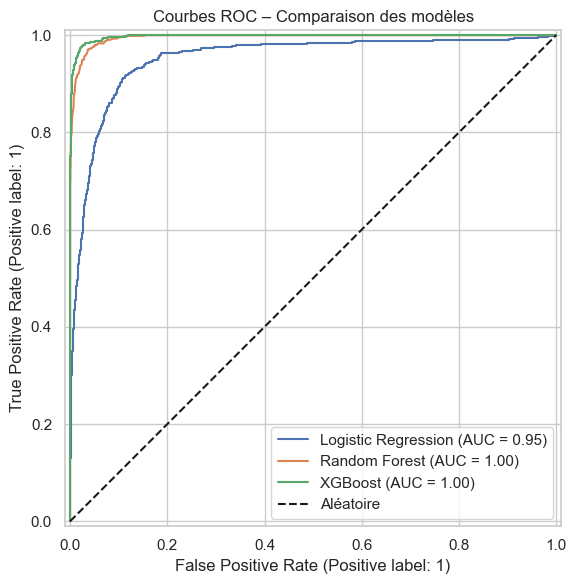

In [ ]:
fig_roc = plot_roc_curves(trained_models, X_test, y_test)
plt.show()

### 4.5 Importance des features (Random Forest & XGBoost)

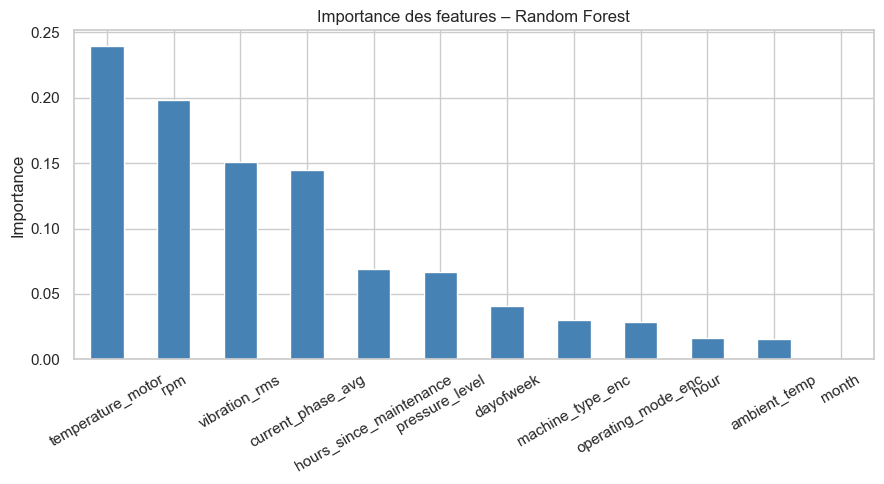

temperature_motor          0.239611
rpm                        0.198397
vibration_rms              0.150672
current_phase_avg          0.144617
hours_since_maintenance    0.069272
pressure_level             0.067100
dayofweek                  0.040503
machine_type_enc           0.030047
operating_mode_enc         0.028216
hour                       0.016097
ambient_temp               0.015467
month                      0.000000
dtype: float64


In [ ]:
fig_fi, feat_imp_df = plot_feature_importance(trained_models, FEATURES)
plt.show()
feat_imp_df

## 5. Conclusion

### Resume
- **Trois modeles entraines** : Logistic Regression, Random Forest, XGBoost
- **Metriques** : ROC-AUC, Precision, Recall, F1-score (classes desequilibrees -> Recall prioritaire)
- **Meilleur modele** : Random Forest (compromis performance / interpretabilite)

### Pistes d'amelioration
- Tester SMOTE / under-sampling pour mieux gerer le desequilibre de classes
- Optimisation des hyperparametres (RandomizedSearchCV)
- Ajouter SHAP pour l'explicabilite locale
- Integrer un modele Deep Learning (MLP)
